# Training ReaxFF-nn on rMD17 (malonaldehyde)

**ReaxFF** (van Duin *et al.*, *J. Phys. Chem. A* 105, 9396, 2001) is the
bond-order *reactive* force field: every valence term is written in terms of
distance-derived bond orders, so bonds can break and form smoothly, and
partial charges are re-equilibrated at every geometry (EEM). **ReaxFF-nn**
(Guo *et al.*, *Comput. Mater. Sci.* 172, 109393, 2020; Xue *et al.*, *PCCP*
23, 19457, 2021) replaces the closed-form bond-order correction (and,
optionally, the bond energy) with small per-species / per-bond neural
networks — turning the force field into a machine-learning potential whose
*every* parameter is trainable by gradient descent, while keeping the
physically-motivated ReaxFF functional form for everything else (angles,
torsions, EEM electrostatics, van der Waals, hydrogen bonds).

This notebook does what the `ffnn` family exists for: it **trains a force
field**. Starting from a generic, untrained seed library
(`xnn.ffnn.models.template_library` — plausible radii, valences and EEM
values, randomly initialized networks), it fits energies **and forces** of
the rMD17 *malonaldehyde* trajectory (PBE/def2-SVP). The sampled conformer is
the dialdehyde form, O=CH–CH₂–CH=O — a small conjugated molecule whose
chemically distinct bonds (C=O double bonds, C–C single bonds, aldehyde and
methylene C–H) are exactly what a bond-order force field has to resolve. Two
kinds of parameters are trained at once:

* the **message-passing bond-order network** `fm` (the ReaxFF-nn core, one
  small all-sigmoid network per element), with the bond energy kept in its
  classical Morse-like form (`EnergyFunction = 0`) so that the dissociation
  limit stays tied to the physical `Desi` parameters — the fully-neural bond
  energy (`EnergyFunction = 1`) is available via
  `template_library(..., energy_function=1)`;
* a set of **classical parameter groups** (bond dissociation energies,
  valence-angle and torsion prefactors, ...) refit by backprop — the other
  headline of this family. Exponent-type parameters (bond-order decay rates,
  the `V2` torsion envelope, vdW steepness) are deliberately kept frozen:
  they control the *asymptotics* of the force field, which equilibrium-only
  training data cannot constrain.

The trained model is exported back to a portable `ffield.json` library, which
the companion notebook `reaxff_md_bond_orders.ipynb` uses for molecular
dynamics, bond-order and charge analysis, and a bond-dissociation study. Both
notebooks also compare against the **original classical ReaxFF** with
published parameters — the same `ReaxFF` class runs a standard `ffield` text
file directly, networks and training entirely optional.

## 0. Setup and data

In [1]:
import io, os, re, time, warnings
warnings.filterwarnings("ignore")
import contextlib

import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
rng = np.random.default_rng(0)

from xnn.common.data import load_dataset, AtomicDataset, collate

# rMD17 malonaldehyde: C3H4O2, 9 atoms, 100k configurations sampled at 500 K,
# recomputed at PBE/def2-SVP. A modest subsample keeps this notebook to a few
# minutes of CPU time.
structures = load_dataset("rmd17", molecule="malonaldehyde", split="train")
idx = rng.permutation(len(structures))[:800]
subset = [structures[i] for i in idx]
n_train, n_val = 640, 80

energies = np.array([s["energy"] for s in subset])
print(f"{len(subset)} structures of {len(subset[0]['atomic_numbers'])} atoms; "
      f"energy spread {1000 * energies.std():.0f} meV (std), "
      f"range {1000 * np.ptp(energies):.0f} meV")

rmd17:malonaldehyde train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:malonaldehyde test:   0%|          | 0/1000 [00:00<?, ? struct/s]

800 structures of 9 atoms; energy spread 189 meV (std), range 1338 meV


## 1. The seed force field

`template_library` builds a complete-but-untrained ReaxFF-nn parameter
library. Its bond-order exponentials are anchored so that BO(rₑ) ≈ 0.85 at
the covalent bond length and BO ≈ 10⁻⁴ at the neighbor-list cutoff — bond
orders (and with them every valence term) then vanish smoothly at the list
boundaries, which is what keeps molecular dynamics conservative. It is a
*starting point*, not a validated force field. The only calibration done by
hand is the per-element reference energies (`atomic`), initialized so the
seed model's mean energy matches the data (rMD17 stores absolute DFT
energies); they stay trainable so the optimizer can refine the offset.

In [2]:
from xnn.ffnn.models import template_library, ReaxFF

lib = template_library(["C", "H", "O"], nn=True, seed=0, energy_function=0)
seed_model = ReaxFF(lib, trainable=("atomic",))

calib = collate([AtomicDataset(subset[:32], cutoff=seed_model.cutoff)[i]
                 for i in range(32)])
with torch.no_grad():
    shift = (seed_model(calib)["energy"].mean() - calib.energy.mean()) / 9
    seed_model.params["atomic"] += shift

os.makedirs("runs/reaxff_rmd17", exist_ok=True)
seed_path = "runs/reaxff_rmd17/ffield_seed.json"
seed_model.export_library().save(seed_path)
print(f"seed library written to {seed_path} "
      f"(atomic-energy shift {float(shift):+.1f} eV/atom)")

seed library written to runs/reaxff_rmd17/ffield_seed.json (atomic-energy shift +806.4 eV/atom)


## 2. Train through the standard `xnn` pipeline

The model registers as `"reaxff"`, so the usual config → `Trainer` route
applies. `trainable` lists the classical parameter groups the optimizer may
refit alongside the (always-trainable) ReaxFF-nn networks. The loss is the
standard per-atom energy + force objective; forces differentiate the whole
functional form (EEM solve included), which is what makes classical-parameter
refitting by backprop work.

In [3]:
from xnn.common.config import from_dict
from xnn.common.train import Trainer

cfg = from_dict({
    "model": {
        "name": "reaxff",
        "cutoff": 10.0,                      # nonbonded/EEM cutoff (standard)
        "ffield": seed_path,
        "trainable": ["atomic", "Desi", "Depi", "Depp", "ovun1",
                      "ang_val1", "ang_val2", "ang_theta0",
                      "tor_V1", "tor_V2", "tor_V3"],
    },
    "data": {"cutoff": 10.0, "batch_size": 16},
    "optim": {"lr": 5e-3, "epochs": 300, "energy_weight": 1.0,
              "force_weight": 0.3, "scheduler": "cosine"},
    "device": "cpu",
    "output_dir": "runs/reaxff_rmd17",
})

train_set = AtomicDataset(subset[:n_train], cutoff=cfg.model.cutoff)
val_set = AtomicDataset(subset[n_train:n_train + n_val],
                        cutoff=cfg.model.cutoff)
test_set = AtomicDataset(subset[n_train + n_val:], cutoff=cfg.model.cutoff)

trainer = Trainer(cfg, train_set, val_set, test_set)
t0 = time.time()
log = io.StringIO()
with contextlib.redirect_stdout(log):
    history = trainer.fit()
print(f"trained {cfg.optim.epochs} epochs in {time.time() - t0:.0f} s")
print("final:", {k: {m: round(float(x), 5) for m, x in v.items()}
                 for k, v in history.items()})

trained 300 epochs in 563 s
final: {'train': {'energy_mse': 0.00014, 'force_mse': 0.25271, 'loss': 0.07595}, 'val': {'energy_mse': 0.0001, 'force_mse': 0.21473, 'loss': 0.06452}, 'test': {'energy_mse': 0.00013, 'force_mse': 0.21937, 'loss': 0.06594}}


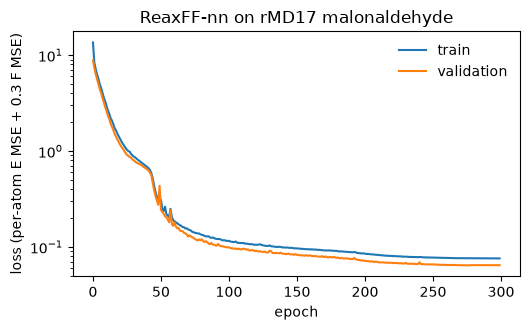

In [4]:
# learning curve, parsed from the trainer's per-epoch log
epochs, tr_loss, va_loss = [], [], []
for line in log.getvalue().splitlines():
    m = re.match(r"epoch\s+(\d+) \| train loss ([\d.e+-]+|nan)"
                 r" \| val loss ([\d.e+-]+|nan)", line)
    if m:
        epochs.append(int(m.group(1)))
        tr_loss.append(float(m.group(2)))
        va_loss.append(float(m.group(3)))

fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.semilogy(epochs, tr_loss, label="train")
ax.semilogy(epochs, va_loss, label="validation")
ax.set_xlabel("epoch")
ax.set_ylabel("loss (per-atom E MSE + 0.3 F MSE)")
ax.set_title("ReaxFF-nn on rMD17 malonaldehyde")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("reaxff_loss_curves.png", dpi=150)
plt.show()

## 3. Test-set accuracy: original vs seed vs trained

Energy and force parity on held-out configurations. Besides the seed and the
trained libraries, the same test set is evaluated with the **original
classical ReaxFF**: the published C/H/O combustion parameterization of
Chenoweth, van Duin and Goddard (*J. Phys. Chem. A* 112, 1040, 2008), read
directly from the SEAMM `.frc` force-field format (`CHO_cho_2008` (shipped with `xnn` in the SEAMM `.frc` format), shipped
alongside this notebook). Nothing about it is fitted to this data — it uses
its own absolute energy reference, so a constant offset (fitted on the
training split) is removed before comparing energies. It anchors the
comparison: transferable published parameters cover all of C/H/O combustion
chemistry at once, but malonaldehyde's conjugated dialdehyde backbone is far
from that parameterization target, and both metrics show it.

A classical functional form with a small message network will not reach the
meV accuracy of large descriptor/GNN models on this benchmark — the point of
a learnable force field is different: a **physically interpretable,
reactive, portable** parameterization (every fitted number is still a ReaxFF
parameter) whose accuracy improves systematically as more parameter groups,
data and epochs are allowed. Note also what the fit cannot know: the
training data samples thermal (≤ 500 K) configurations only, so regions far
off that manifold — stretched bonds, close contacts — inherit the seed's
generic parameters rather than data (the companion notebook makes this
concrete, including where the *original* field in turn beats the trained
one).

original E MAE    811.4 meV | F MAE  5.917 eV/A
seed     E MAE    905.0 meV | F MAE  4.943 eV/A
trained  E MAE     82.7 meV | F MAE  0.350 eV/A


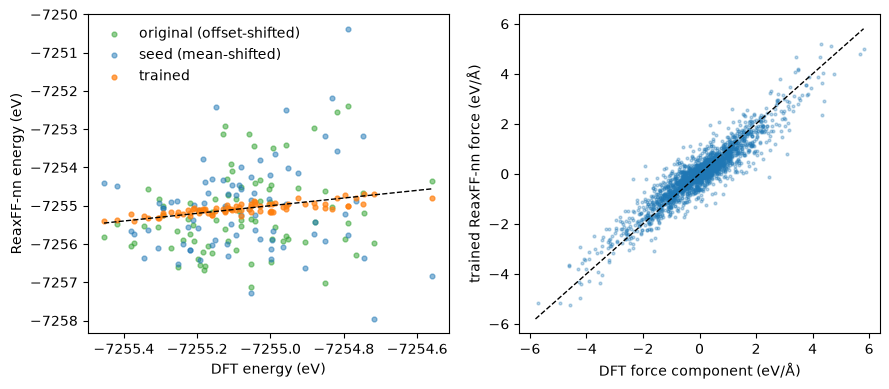

In [5]:
from xnn.common.models import ForceStressOutput

model = trainer.module.model          # the trained ReaxFF inside the wrapper
fs = trainer.module
model.eval()


def collect(wrapped):
    es, fs_ = [], []
    for i in range(len(test_set)):
        out = wrapped(test_set[i])
        es.append(float(out["energy"][0]))
        fs_.append(out["forces"].detach().numpy())
    return np.array(es), np.concatenate([f.ravel() for f in fs_])


seed_model2 = ReaxFF(seed_path)           # untouched seed, for comparison
e_seed, f_seed = collect(ForceStressOutput(seed_model2))
e_pred, f_pred = collect(fs)
e_ref = np.array([float(test_set[i].energy[0]) for i in range(len(test_set))])
f_ref = np.concatenate([test_set[i].forces.numpy().ravel()
                        for i in range(len(test_set))])

# the original published field, read from the standard ffield text format;
# its constant energy reference is fitted on (a sample of) the training split
orig_model = ForceStressOutput(ReaxFF("CHO_cho_2008"))
off = np.mean([float(orig_model(train_set[i])["energy"][0])
               - float(train_set[i].energy[0]) for i in range(0, n_train, 10)])
e_orig, f_orig = collect(orig_model)
e_orig -= off

for name, e, f in (("original", e_orig, f_orig), ("seed", e_seed, f_seed),
                   ("trained", e_pred, f_pred)):
    print(f"{name:8s} E MAE {1000 * np.abs(e - e_ref).mean():8.1f} meV | "
          f"F MAE {np.abs(f - f_ref).mean():6.3f} eV/A")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
lo, hi = e_ref.min(), e_ref.max()
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[0].scatter(e_ref, e_orig, s=12, alpha=0.5, color="C2",
                label="original (offset-shifted)")
axes[0].scatter(e_ref, e_seed - e_seed.mean() + e_ref.mean(), s=12,
                alpha=0.5, label="seed (mean-shifted)")
axes[0].scatter(e_ref, e_pred, s=12, alpha=0.7, label="trained")
axes[0].set_xlabel("DFT energy (eV)")
axes[0].set_ylabel("ReaxFF-nn energy (eV)")
axes[0].legend(frameon=False)
lim = np.abs(f_ref).max()
axes[1].plot([-lim, lim], [-lim, lim], "k--", lw=1)
axes[1].scatter(f_ref, f_pred, s=4, alpha=0.3)
axes[1].set_xlabel("DFT force component (eV/Å)")
axes[1].set_ylabel("trained ReaxFF-nn force (eV/Å)")
fig.tight_layout()
fig.savefig("reaxff_parity.png", dpi=150)
plt.show()

## 4. Export the trained force field

`export_library()` unpacks the trained tensors back into a flat parameter
library (energies in kcal/mol, networks included) and `save` writes it in
the ReaxFF-nn JSON format — a portable artifact: reload it here with
`ReaxFF("runs/reaxff_rmd17/ffield_trained.json")`, or hand it to other
ReaxFF-nn-aware codes. And because every fitted number is still a ReaxFF
parameter, the result can be *read*: the refit sigma-bond dissociation
energies below are the force field's own statement of how strong it now
thinks each bond is.

In [6]:
trained_path = "runs/reaxff_rmd17/ffield_trained.json"
model.export_library().save(trained_path)

# round-trip check: the reloaded library reproduces the trained model
# (to float32 round-off of the kcal/mol<->eV conversions; exact in float64)
reloaded = ReaxFF(trained_path)
g = test_set[0]
diff = abs(float(reloaded(g)["energy"][0]) - float(model(g)["energy"][0]))
print(f"saved {trained_path}; reload round-trip |dE| = {diff:.2e} eV")

lib_out = reloaded.export_library()
print("refit sigma-bond dissociation energies (seed value: 120 kcal/mol):")
for bd in ("C-O", "C-C", "C-H", "H-O"):
    key = f"Desi_{bd}" if f"Desi_{bd}" in lib_out.p else \
        f"Desi_{'-'.join(reversed(bd.split('-')))}"
    print(f"  {bd}: {lib_out.p[key]:7.1f} kcal/mol")

saved runs/reaxff_rmd17/ffield_trained.json; reload round-trip |dE| = 0.00e+00 eV
refit sigma-bond dissociation energies (seed value: 120 kcal/mol):
  C-O:   160.9 kcal/mol
  C-C:    48.5 kcal/mol
  C-H:   231.4 kcal/mol
  H-O:    91.3 kcal/mol
